### Parallel Execution

-  Executes agents in parallel which are independent on each other
-  Parallel agent task will meet on certain combine stage to consolidate parallel agent responses.

In [1]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI

load_dotenv()

True

In [2]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)

In [3]:
import operator
from typing import Annotated, List


class AgentState(TypedDict):
    input_text: str
    parallel_outputs: Annotated[list, operator.add]
    response: str

In [4]:
# Node 1_1:Summarize Handler 
def summarize_handler(state: AgentState):
    messages = [
        {"role": "system", "content": "Summarize the following text briefly."},
        {"role": "user", "content": state['input_text']}
    ]

    response = model.invoke(messages)
    summary = response.content.strip()
    print("Summary:", summary)
    return {"parallel_outputs": [f"Summary: {summary}"]}

In [5]:
# Node 1_2:Terms Handler 
def terms_handler(state: AgentState):
    messages = [
        {"role": "system", "content": "Identify 3-5 key terms from the following text, separated by commas."},
        {"role": "user", "content": state['input_text']}
    ]

    response = model.invoke(messages)
    state['terms'] = response.content.strip()
    print("Terms:", state['terms'])
    terms = response.content.strip()
    return {"parallel_outputs": [f"Terms: {terms}"]}

In [6]:
# Node 1_3:Questions Handler 
def questions_handler(state: AgentState) -> AgentState:
    messages = [
        {"role": "system", "content": "Generate 2-3 interesting questions about the following text, separated by commas."},
        {"role": "user", "content": state['input_text']}
    ]

    response = model.invoke(messages)
    questions = response.content.strip()
    print("Questions:", questions)
    return {"parallel_outputs": [f"Questions: {questions}"]}

In [7]:
# Node 2: Combine parallel results
def combine_results_handler(state: AgentState) -> AgentState:
    parallel_inputs = "\n\n".join(state['parallel_outputs'])
    system_prompt = f"""
    Based on the following inputs, synthesize a compreshensive answer.
    {parallel_inputs}
    """
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"Original Topic: {state['input_text']}"}
    ]

    response = model.invoke(messages)
    state['response'] = response.content.strip()
    print("Final Response:", state['response'])
    return state

In [8]:
workflow =  StateGraph(AgentState)
workflow.add_node("summarize", summarize_handler)
workflow.add_node("terms", terms_handler)
workflow.add_node("questions", questions_handler) 
workflow.add_node("combine_results", combine_results_handler)
workflow.add_edge(START, "summarize")
workflow.add_edge(START, "terms")
workflow.add_edge(START, "questions")
workflow.add_edge("summarize", "combine_results")
workflow.add_edge("terms", "combine_results")
workflow.add_edge("questions", "combine_results")
workflow.add_edge("combine_results", END)

graph = workflow.compile()

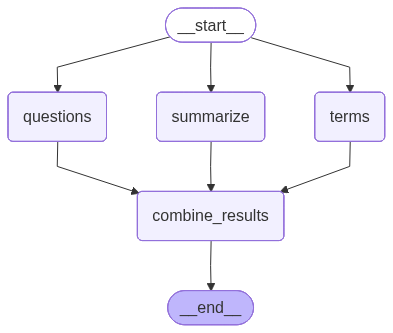

In [9]:
from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod

graph_image = graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.API
)

display(Image(graph_image))

In [10]:
test_topic = "The history of space exploration"
response = graph.invoke({
    "input_text": test_topic
})
print("Result:", response)

Terms: space exploration, history, exploration, space
Questions: What were some of the key milestones in the history of space exploration, How have technological advancements influenced the progress of space exploration over the decades, In what ways has international collaboration shaped the future of space exploration?
Summary: The history of space exploration began with early astronomical observations and evolved through the development of rocketry in the 20th century. Key milestones include the launch of Sputnik 1 by the Soviet Union in 1957, marking the first artificial satellite, followed by human spaceflight with Yuri Gagarin in 1961. The Apollo program culminated in the Moon landing in 1969. Subsequent decades saw advancements in robotic missions, the Space Shuttle program, and the construction of the International Space Station. Recent efforts focus on Mars exploration, private space travel, and plans for future missions to the Moon and beyond.
Final Response: The history of s